In [33]:
import os, sys
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# === Cau hinh ===
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

ROOT = Path.cwd()
if ROOT.name == 'examples':
    ROOT = ROOT.parent
backend_path = ROOT / 'backend'
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))
    sys.path.insert(0, str(ROOT))

IMAGE_PATH = PROJECT_ROOT / "sam3" / "assets" / "images" / "composite.png"
MASK_A_PATH = PROJECT_ROOT / "sam3" / "masks" / "raw_mask_4.png"   # occluder
MASK_B_PATH = PROJECT_ROOT / "sam3" / "09_amodal_mask_sample1_original_size.png"  # target

DEVICE = "cuda"
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")


Device: cuda
Project root: /home/intern


## 2. Tai anh & mask


In [34]:
# Tai anh
image = Image.open(IMAGE_PATH).convert("RGB")
orig_w, orig_h = image.size
# image_512 = image.resize((512, 512))
# img_np = np.array(image_512, dtype=np.uint8)
img_np = np.array(image, dtype=np.uint8)

# Tai mask
mask_A_pil = Image.open(MASK_A_PATH).convert("L")
mask_B_pil = Image.open(MASK_B_PATH).convert("L")

# mask_A_512 = np.array(mask_A_pil.resize((512, 512)))
# mask_B_512 = np.array(mask_B_pil.resize((512, 512)))

# mask_A_bool = mask_A_512 > 128
# mask_B_bool = mask_B_512 > 128

mask_A_bool = np.array(mask_A_pil) > 128
mask_B_bool = np.array(mask_B_pil) > 128

overlap = mask_A_bool & mask_B_bool
print(f"Image: {orig_w}x{orig_h}")
print(f"A (occluder): {mask_A_bool.sum()} px")
print(f"B (target):   {mask_B_bool.sum()} px")
print(f"Overlap:      {overlap.sum()} px")


Image: 6614x4252
A (occluder): 1382887 px
B (target):   1230104 px
Overlap:      180526 px


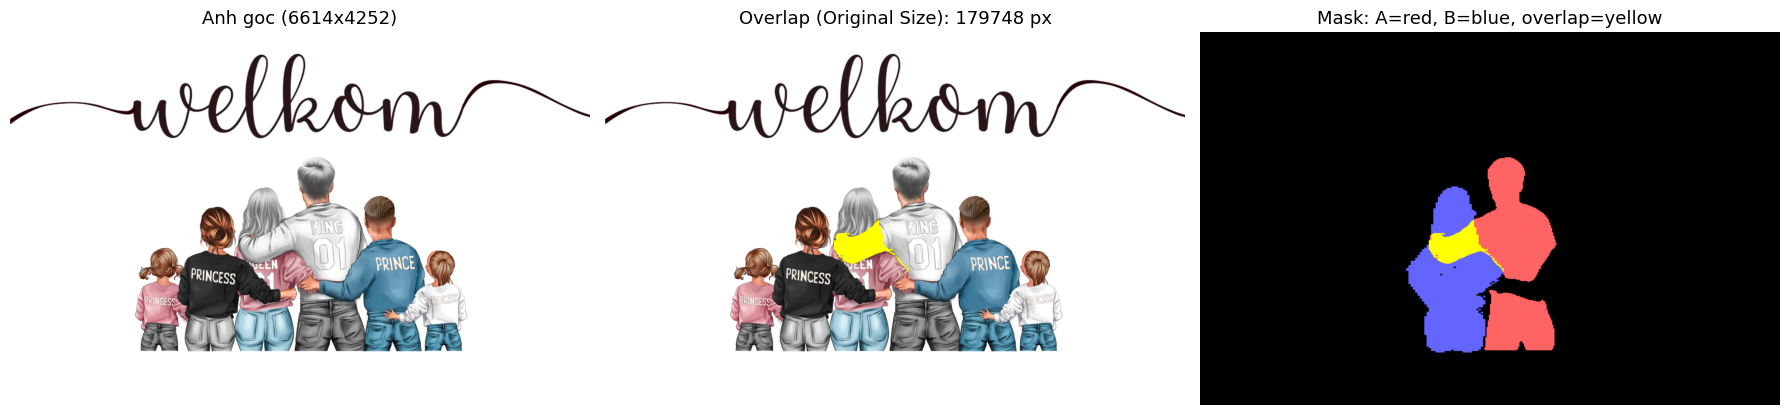

In [27]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def resize_mask_to_orig(mask_bool_512, w, h):
    mask_uint8 = (mask_bool_512.astype(np.uint8) * 255)
    mask_resized = Image.fromarray(mask_uint8).resize((w, h), resample=Image.NEAREST)
    return np.array(mask_resized) > 128

mask_A_orig_bool = resize_mask_to_orig(mask_A_bool, orig_w, orig_h)
mask_B_orig_bool = resize_mask_to_orig(mask_B_bool, orig_w, orig_h)
overlap_orig_bool = resize_mask_to_orig(overlap, orig_w, orig_h)

img_np_orig = np.array(image)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_np_orig)
axes[0].set_title(f"Anh goc ({orig_w}x{orig_h})", fontsize=13)
axes[0].axis("off")

overlay = img_np_orig.copy()

overlay[overlap_orig_bool] = [255, 255, 0]  # yellow
axes[1].imshow(overlay)
axes[1].set_title(f"Overlap (Original Size): {overlap_orig_bool.sum()} px", fontsize=13)
axes[1].axis("off")

mask_vis = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
mask_vis[mask_A_orig_bool] = [255, 100, 100]  # red = A
mask_vis[mask_B_orig_bool] = [100, 100, 255]  # blue = B
mask_vis[overlap_orig_bool] = [255, 255, 0]   # yellow = overlap

axes[2].imshow(mask_vis)
axes[2].set_title("Mask: A=red, B=blue, overlap=yellow", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from simple_lama_inpainting import SimpleLama
from backend.helpers import refine_background

lama = SimpleLama()

mask_A_uint8 = (mask_A_bool.astype(np.uint8) * 255)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.uint8)
mask_for_lama_512_np = cv2.dilate(mask_A_uint8, kernel, iterations=1)
mask_for_lama_512_pil = Image.fromarray(mask_for_lama_512_np)

print("Running LaMa Inpainting at 512x512...")
with torch.no_grad():
    result_512_pil = lama(image, mask_for_lama_512_pil)

# result_upscaled_np = np.array(result_512_pil.resize((orig_w, orig_h), resample=Image.LANCZOS))

# img_np_orig = np.array(image)
# final_result_np = img_np_orig.copy()

# def apply_ultra_soft_amodal_blending(img_orig, img_inpaint, overlap_mask_bool):
#     """
#     Sử dụng phương pháp làm mờ siêu mạnh và tinh chỉnh Gamma 
#     để hòa trộn vùng Inpaint vào vùng Overlap.
#     """
#     # 1. Đưa ảnh về dạng float32 để tính toán chính xác
#     img_orig_f = img_orig.astype(np.float32)
#     img_inpaint_f = img_inpaint.astype(np.float32)
    
#     # 2. Tạo Mask dải mờ từ Overlap Mask
#     # Chuyển bool sang float [0, 1]
#     mask_f = overlap_mask_bool.astype(np.float32)
    
#     # 3. Áp dụng GAUSSIAN BLUR SIÊU MẠNH (Phương pháp 3 của bạn)
#     # Kernel lớn (31, 31) hoặc (61, 61) tùy độ phân giải ảnh gốc
#     mask_soft = cv2.GaussianBlur(mask_f, (41, 41), 0)
    
#     # 4. TINH CHỈNH GAMMA (Độ cong dải mờ)
#     # Mũ 1.6 giúp dải mờ chuyển đổi tự nhiên hơn, không bị đều đều (linear)
#     mask_soft = mask_soft ** 1.6
    
#     # 5. CLAMPING & REFINING (Chốt lõi và cắt nhiễu viền)
#     mask_soft[mask_soft < 0.02] = 0.0  # Xóa sạch pixel thừa ở biên ngoài
#     mask_soft[mask_soft > 0.98] = 1.0  # Giữ lõi của vật thể B luôn đặc (không bị mờ)
    
#     # Mở rộng chiều để nhân với ảnh RGB
#     mask_soft_3d = np.expand_dims(mask_soft, axis=2)
    
#     # 6. TRỘN ẢNH (ALPHA BLENDING)
#     # Công thức: (Ảnh_Inpaint * Mask) + (Ảnh_Gốc * (1 - Mask))
#     final_result = img_inpaint_f * mask_soft_3d + img_orig_f * (1 - mask_soft_3d)
    
#     # 7. Ép kiểu về uint8
#     final_result = np.clip(final_result, 0, 255).astype(np.uint8)
    
#     return final_result

# final_result_np = apply_ultra_soft_amodal_blending(img_np_orig, result_upscaled_np, overlap_orig_bool)


# final_result_np[overlap_orig_bool] = result_upscaled_np[overlap_orig_bool]

final_result_np = np.array(result_512_pil)

final_result_np = refine_background(
    bg=final_result_np,              # Ảnh đã dán miếng vá LaMa
    mask=overlap_orig_bool,        # Mask vùng đã xóa (kiểu bool)
    n_outer_ratio= 0.2,
    max_num_colors= 10
)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(img_np_orig)
axes[0].set_title(f"1. Anh goc ({orig_w}x{orig_h})", fontsize=13)
axes[0].axis("off")

axes[1].imshow(final_result_np)
axes[1].set_title("2. Sau Inpaint (Vat the A da xoa)", fontsize=13)
axes[1].axis("off")

overlay = final_result_np.copy()
overlay[overlap_orig_bool] = [255, 255, 0]  # yellow
axes[2].imshow(overlay)
axes[2].set_title(f"3. Overlap (Original Size): {overlap_orig_bool.sum()} px", fontsize=13)
axes[2].axis("off")

mask_vis = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
mask_vis[mask_A_orig_bool] = [255, 100, 100]  # red = A
mask_vis[mask_B_orig_bool] = [100, 100, 255]  # blue = B
mask_vis[overlap_orig_bool] = [255, 255, 0]   # yellow = overlap
axes[3].imshow(mask_vis)
axes[3].set_title("4. Mask: A=red, B=blue, overlap=yellow", fontsize=13)
axes[3].axis("off")

plt.tight_layout()
plt.show()

Running LaMa Inpainting at 512x512...


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__.py", line 11, in forward
    mask: Tensor) -> Tensor:
    model = self.model
    return (model).forward(mask, image, )
            ~~~~~~~~~~~~~~ <--- HERE
  File "code/__torch__/saicinpainting/training/trainers/default.py", line 13, in forward
    masked_img = torch.mul(image, torch.rsub(mask, 1))
    input = torch.cat([masked_img, mask], 1)
    _0 = torch.mul(mask, (generator).forward(input, ))
                          ~~~~~~~~~~~~~~~~~~ <--- HERE
    _1 = torch.mul(torch.rsub(mask, 1), image)
    return torch.add(_0, _1)
  File "code/__torch__/saicinpainting/training/modules/ffc.py", line 10, in forward
    input: Tensor) -> Tensor:
    model = self.model
    return (model).forward(input, )
            ~~~~~~~~~~~~~~ <--- HERE
class FFC_BN_ACT(Module):
  __parameters__ = []
  File "code/__torch__/torch/nn/modules/cont

: 